
Evaluating Iris dataset...


C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Evaluating Wine dataset...


C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Evaluating Digits dataset...

Evaluating Breast Cancer dataset...


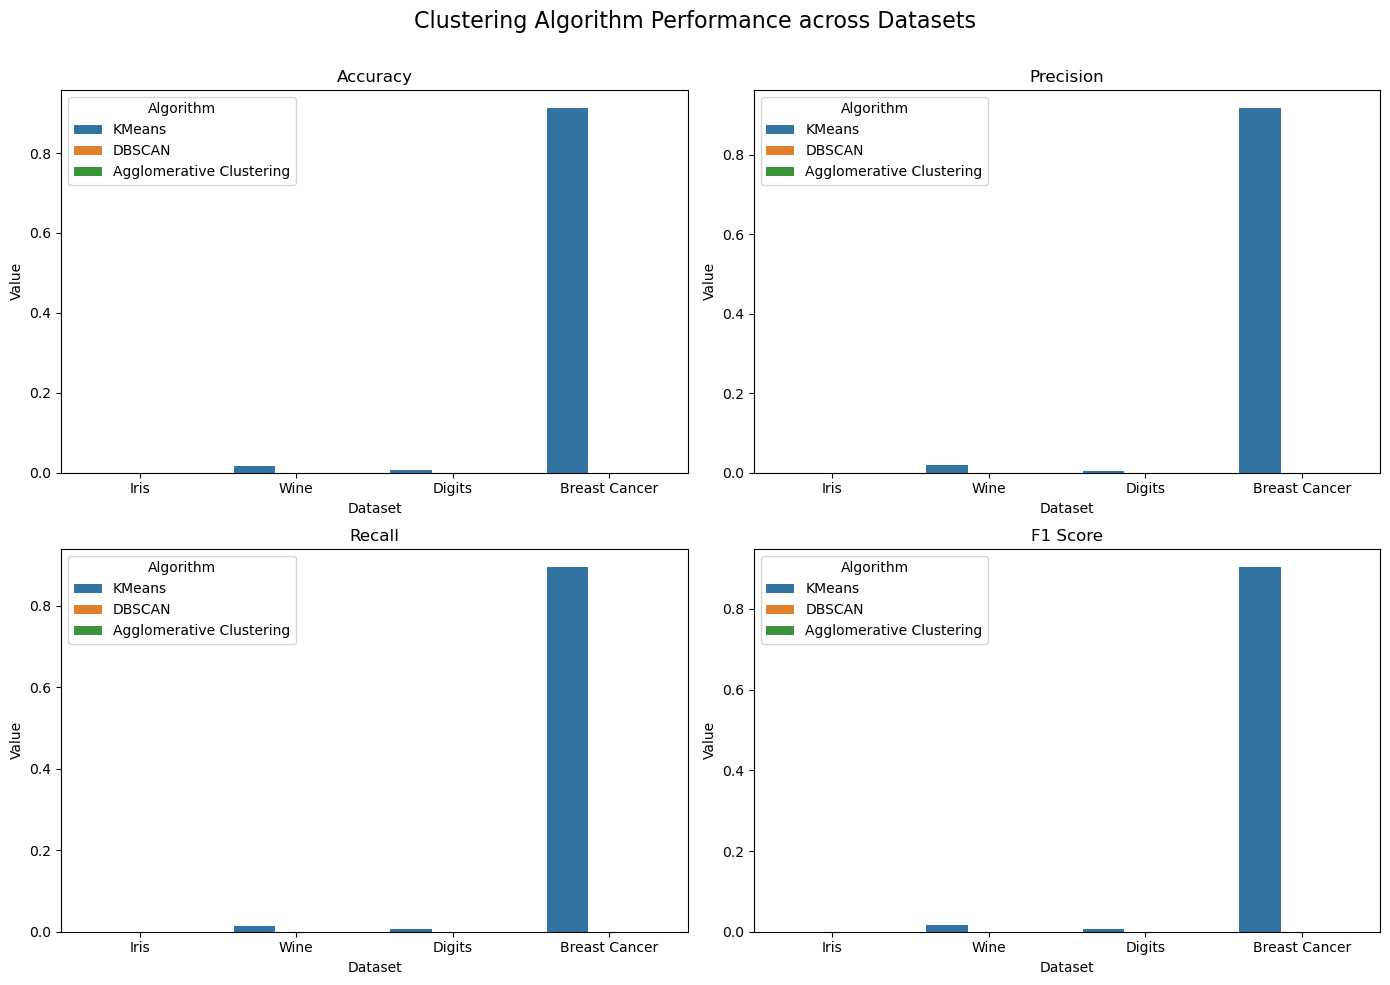

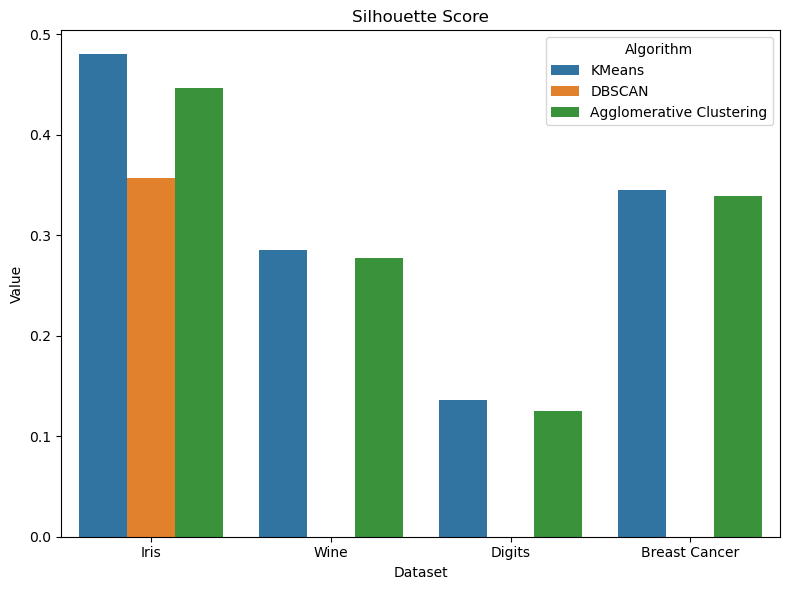

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define function to load dataset
def load_iris_dataset():
    from sklearn.datasets import load_iris
    iris = load_iris()
    data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    data['Class'] = iris.target
    return data

def load_wine_dataset():
    from sklearn.datasets import load_wine
    wine = load_wine()
    data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
    data['Class'] = wine.target
    return data

def load_digits_dataset():
    from sklearn.datasets import load_digits
    digits = load_digits()
    data = pd.DataFrame(data=digits.data)
    data['Class'] = digits.target
    return data

def load_breast_cancer_dataset():
    from sklearn.datasets import load_breast_cancer
    cancer = load_breast_cancer()
    data = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
    data['Class'] = cancer.target
    return data

# Function to preprocess the data
def preprocess_data(data, target_column):
    X = data.drop(target_column, axis=1) if target_column else data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # Scale the features
    return X_scaled

# Function to evaluate unsupervised algorithms
def evaluate_unsupervised_algorithms(X, y_true):
    results = {}
    
    # KMeans clustering
    kmeans = KMeans(n_clusters=len(set(y_true)), random_state=42)
    kmeans.fit(X)
    y_pred_kmeans = kmeans.labels_
    sil_score = silhouette_score(X, y_pred_kmeans)
    results['KMeans'] = {'Silhouette Score': sil_score}
    
    # DBSCAN clustering
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    y_pred_dbscan = dbscan.fit_predict(X)
    if len(set(y_pred_dbscan)) > 1:  # DBSCAN may result in -1 for noise
        sil_score_dbscan = silhouette_score(X, y_pred_dbscan)
        results['DBSCAN'] = {'Silhouette Score': sil_score_dbscan}
    else:
        results['DBSCAN'] = {'Silhouette Score': None}
    
    # Agglomerative clustering
    agglomerative = AgglomerativeClustering(n_clusters=len(set(y_true)))
    y_pred_agglomerative = agglomerative.fit_predict(X)
    sil_score_agglomerative = silhouette_score(X, y_pred_agglomerative)
    results['Agglomerative Clustering'] = {'Silhouette Score': sil_score_agglomerative}
    
    # For metrics: accuracy, precision, recall, and F1 score
    try:
        accuracy = accuracy_score(y_true, y_pred_kmeans)
        precision = precision_score(y_true, y_pred_kmeans, average='macro')  # Handle multiclass by setting average
        recall = recall_score(y_true, y_pred_kmeans, average='macro')  # Handle multiclass by setting average
        f1 = f1_score(y_true, y_pred_kmeans, average='macro')  # Handle multiclass by setting average
        
        results['KMeans'].update({'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})
    except ValueError:
        # In case KMeans does not produce valid labels
        results['KMeans'].update({'Accuracy': None, 'Precision': None, 'Recall': None, 'F1 Score': None})
    
    return results

# Main loop to evaluate all datasets
datasets = {
    "Iris": load_iris_dataset,
    "Wine": load_wine_dataset,
    "Digits": load_digits_dataset,
    "Breast Cancer": load_breast_cancer_dataset
}

results_summary = {}

for dataset_name, load_function in datasets.items():
    print(f'\nEvaluating {dataset_name} dataset...')
    
    # Load dataset
    data = load_function()
    
    # Determine target column for each dataset
    target_column = 'Class'  # All the datasets here have 'Class' as the target column
    
    # Preprocess data
    X = preprocess_data(data, target_column)
    y_true = data[target_column]  # Ground truth labels
    
    # Evaluate unsupervised algorithms on the dataset
    results = evaluate_unsupervised_algorithms(X, y_true)
    
    # Store results
    results_summary[dataset_name] = results

# Prepare data for visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Silhouette Score']
algorithms = ['KMeans', 'DBSCAN', 'Agglomerative Clustering']
results_for_plot = []

for dataset_name, result in results_summary.items():
    for algorithm in algorithms:
        for metric in metrics:
            value = result.get(algorithm, {}).get(metric, None)
            results_for_plot.append({
                'Dataset': dataset_name,
                'Algorithm': algorithm,
                'Metric': metric,
                'Value': value
            })

# Convert results to DataFrame
plot_data = pd.DataFrame(results_for_plot)

# Create subplots for metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clustering Algorithm Performance across Datasets', fontsize=16)

# Plot Accuracy
sns.barplot(x='Dataset', y='Value', hue='Algorithm', data=plot_data[plot_data['Metric'] == 'Accuracy'], ax=axes[0, 0])
axes[0, 0].set_title('Accuracy')

# Plot Precision
sns.barplot(x='Dataset', y='Value', hue='Algorithm', data=plot_data[plot_data['Metric'] == 'Precision'], ax=axes[0, 1])
axes[0, 1].set_title('Precision')

# Plot Recall
sns.barplot(x='Dataset', y='Value', hue='Algorithm', data=plot_data[plot_data['Metric'] == 'Recall'], ax=axes[1, 0])
axes[1, 0].set_title('Recall')

# Plot F1 Score
sns.barplot(x='Dataset', y='Value', hue='Algorithm', data=plot_data[plot_data['Metric'] == 'F1 Score'], ax=axes[1, 1])
axes[1, 1].set_title('F1 Score')

# Adjust layout and show the plot
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Plot Silhouette Score (separate plot)
plt.figure(figsize=(8, 6))
sns.barplot(x='Dataset', y='Value', hue='Algorithm', data=plot_data[plot_data['Metric'] == 'Silhouette Score'])
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()
